In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pymdp
from pymdp import utils

In [2]:
def plot_likelihood(matrix, title_str = "Likelihood distribution (A)"):
    """
    Plots a 2-D likelihood matrix as a heatmap
    """

    if not np.isclose(matrix.sum(axis=0), 1.0).all():
      raise ValueError("Distribution not column-normalized! Please normalize (ensure matrix.sum(axis=0) == 1.0 for all columns)")
    
    fig = plt.figure(figsize = (6,6))
    ax = sns.heatmap(matrix, cmap = 'gray', cbar = False, vmin = 0.0, vmax = 1.0)
    plt.title(title_str)
    plt.show()


def plot_beliefs(belief_dist, title_str=""):
    """
    Plot a categorical distribution or belief distribution, stored in the 1-D numpy vector `belief_dist`
    """

    if not np.isclose(belief_dist.sum(), 1.0):
      raise ValueError("Distribution not normalized! Please normalize")

    plt.grid(zorder=0)
    plt.bar(range(belief_dist.shape[0]), belief_dist, color='r', zorder=3)
    plt.xticks(range(belief_dist.shape[0]))
    plt.title(title_str)
    plt.show()

In [4]:
context_names = ['Left-Better', 'Right-Better']
choice_names = ['Start', 'Hint', 'Left Arm', 'Right Arm']

""" Define `num_states` and `num_factors` below """
num_states = [len(context_names), len(choice_names)]
num_factors = len(num_states)

context_action_names = ['Do-nothing']
choice_action_names = ['Move-start', 'Get-hint', 'Play-left', 'Play-right']

""" Define `num_controls` below """
num_controls = [len(context_action_names), len(choice_action_names)]

hint_obs_names = ['Null', 'Hint-left', 'Hint-right']
reward_obs_names = ['Null', 'Loss', 'Reward']
choice_obs_names = ['Start', 'Hint', 'Left Arm', 'Right Arm']

""" Define `num_obs` and `num_modalities` below """
num_obs = [len(hint_obs_names), len(reward_obs_names), len(choice_obs_names)]
num_modalities = len(num_obs)

A array

In [5]:
""" Generate the A array """
A = utils.obj_array( num_modalities )

A hint modality

In [ ]:
p_hint = 0.7 # accuracy of the hint, according to the agent's generative model (how much does the agent trust the hint?)

A_hint = np.zeros( (len(hint_obs_names), len(context_names), len(choice_names)) )

for choice_id, choice_name in enumerate(choice_names):

  if choice_name == 'Start':
B = utils.obj_array(num_factors)
    A_hint[0,:,choice_id] = 1.0
  
  elif choice_name == 'Hint':

    A_hint[1:,:,choice_id] = np.array([[p_hint,       1.0 - p_hint],
                                      [1.0 - p_hint,  p_hint]])
  elif choice_name == 'Left Arm':

    A_hint[0,:,choice_id] = 1.0
  
  elif choice_name == 'Right Arm':

    A_hint[0,:,choice_id] = 1.0
  
A[0] = A_hint

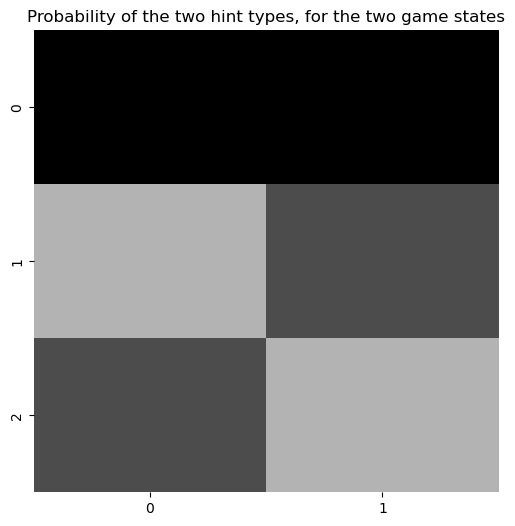

In [8]:
plot_likelihood(A[0][:,:,1], title_str = "Probability of the two hint types, for the two game states")


A reward modality

In [9]:
p_reward = 0.8 # probability of getting a rewarding outcome, if you are sampling the more rewarding bandit

A_reward = np.zeros((len(reward_obs_names), len(context_names), len(choice_names)))

for choice_id, choice_name in enumerate(choice_names):

  if choice_name == 'Start':

    A_reward[0,:,choice_id] = 1.0
  
  elif choice_name == 'Hint':

    A_reward[0,:,choice_id] = 1.0
  
  elif choice_name == 'Left Arm':

    A_reward[1:,:,choice_id] = np.array([ [1.0-p_reward, p_reward], 
                                        [p_reward, 1.0-p_reward]])
  elif choice_name == 'Right Arm':

    A_reward[1:, :, choice_id] = np.array([[ p_reward, 1.0- p_reward], 
                                         [1- p_reward, p_reward]])
  
A[1] = A_reward

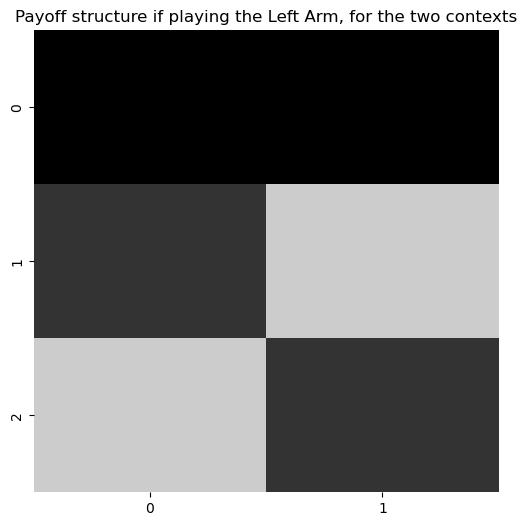

In [10]:
plot_likelihood(A[1][:,:,2], 'Payoff structure if playing the Left Arm, for the two contexts')


A choice observation modality

In [11]:
A_choice = np.zeros((len(choice_obs_names), len(context_names), len(choice_names)))

for choice_id in range(len(choice_names)):

  A_choice[choice_id, :, choice_id] = 1.0

A[2] = A_choice

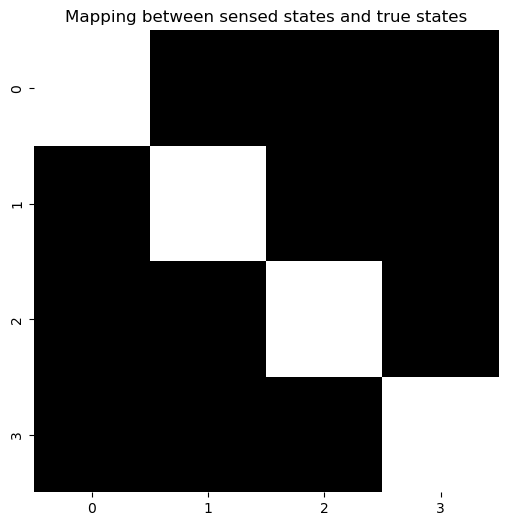

In [12]:
""" Condition on context (first hidden state factor) and display the remaining indices (outcome and choice state) """

plot_likelihood(A[2][:,0,:], "Mapping between sensed states and true states")

B array

In [14]:
B = utils.obj_array(num_factors)

B context

In [15]:
B_context = np.zeros( (len(context_names), len(context_names), len(context_action_names)) )

B_context[:,:,0] = np.eye(len(context_names))

B[0] = B_context

B choice factor

In [16]:
B_choice = np.zeros( (len(choice_names), len(choice_names), len(choice_action_names)) )

for choice_i in range(len(choice_names)):
  
  B_choice[choice_i, :, choice_i] = 1.0

B[1] = B_choice

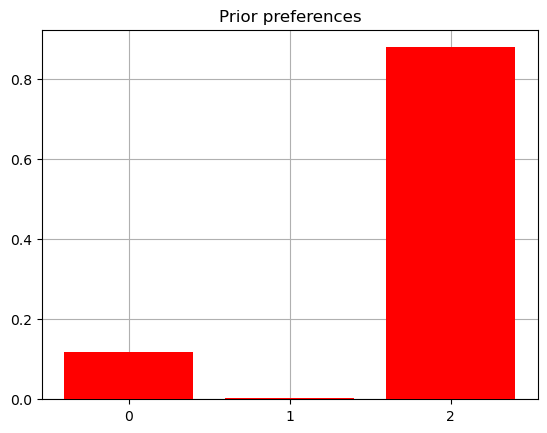

In [17]:
""" Explain `obj_array_zeros` and how you don't have to populate them necessarily """
C = utils.obj_array_zeros(num_obs)

from pymdp.maths import softmax

C_reward = np.zeros(len(reward_obs_names))
C_reward[1] = -4.0 
C_reward[2] = 2.0 

C[1] = C_reward

plot_beliefs(softmax(C_reward), title_str = "Prior preferences")





In [18]:
D = utils.obj_array(num_factors)

D_context = np.array([0.5,0.5])

D[0] = D_context

D_choice = np.zeros(len(choice_names))

D_choice[choice_names.index("Start")] = 1.0

D[1] = D_choice

print(f'Beliefs about which arm is better: {D[0]}')
print(f'Beliefs about starting location: {D[1]}')

Beliefs about which arm is better: [0.5 0.5]
Beliefs about starting location: [1. 0. 0. 0.]


Agent code:

In [19]:
from pymdp.agent import Agent

my_agent = Agent(A = A, B = B, C = C, D = D)

In [20]:
class TwoArmedBandit(object):

  def __init__(self, context = None, p_hint = 1.0, p_reward = 0.8):

    self.context_names = ["Left-Better", "Right-Better"]

    if context == None:
      self.context = self.context_names[utils.sample(np.array([0.5, 0.5]))] # randomly sample which bandit arm is better (Left or Right)
    else:
      self.context = context

    self.p_hint = p_hint
    self.p_reward = p_reward

    self.reward_obs_names = ['Null', 'Loss', 'Reward']
    self.hint_obs_names = ['Null', 'Hint-left', 'Hint-right']

  def step(self, action):

    if action == "Move-start":
      observed_hint = "Null"
      observed_reward = "Null"
      observed_choice = "Start"
    elif action == "Get-hint":
      if self.context == "Left-Better":
        observed_hint = self.hint_obs_names[utils.sample(np.array([0.0, self.p_hint, 1.0 - self.p_hint]))]
      elif self.context == "Right-Better":
        observed_hint = self.hint_obs_names[utils.sample(np.array([0.0, 1.0 - self.p_hint, self.p_hint]))]
      observed_reward = "Null"
      observed_choice = "Hint"
    elif action == "Play-left":
      observed_hint = "Null"
      observed_choice = "Left Arm"
      if self.context == "Left-Better":
        observed_reward = self.reward_obs_names[utils.sample(np.array([0.0, 1.0 - self.p_reward, self.p_reward]))]
      elif self.context == "Right-Better":
        observed_reward = self.reward_obs_names[utils.sample(np.array([0.0, self.p_reward, 1.0 - self.p_reward]))]
    elif action == "Play-right":
      observed_hint = "Null"
      observed_choice = "Right Arm"
      if self.context == "Right-Better":
        observed_reward = self.reward_obs_names[utils.sample(np.array([0.0, 1.0 - self.p_reward, self.p_reward]))]
      elif self.context == "Left-Better":
        observed_reward = self.reward_obs_names[utils.sample(np.array([0.0, self.p_reward, 1.0 - self.p_reward]))]
    
    obs = [observed_hint, observed_reward, observed_choice]

    return obs

In [21]:
def run_active_inference_loop(my_agent, my_env, T = 5):

  """ Initialize the first observation """
  obs_label = ["Null", "Null", "Start"]  # agent observes itself seeing a `Null` hint, getting a `Null` reward, and seeing itself in the `Start` location
  obs = [hint_obs_names.index(obs_label[0]), reward_obs_names.index(obs_label[1]), choice_obs_names.index(obs_label[2])]
  
  for t in range(T):
    qs = my_agent.infer_states(obs)
    plot_beliefs(qs[0], title_str = f"Beliefs about the context at time {t}")

    q_pi, efe = my_agent.infer_policies()
    chosen_action_id = my_agent.sample_action()

    movement_id = int(chosen_action_id[1])

    choice_action = choice_action_names[movement_id]

    obs_label = my_env.step(choice_action)

    obs = [hint_obs_names.index(obs_label[0]), reward_obs_names.index(obs_label[1]), choice_obs_names.index(obs_label[2])]

    print(f'Action at time {t}: {choice_action}')
    print(f'Reward at time {t}: {obs_label[1]}')

Context: Right-Better


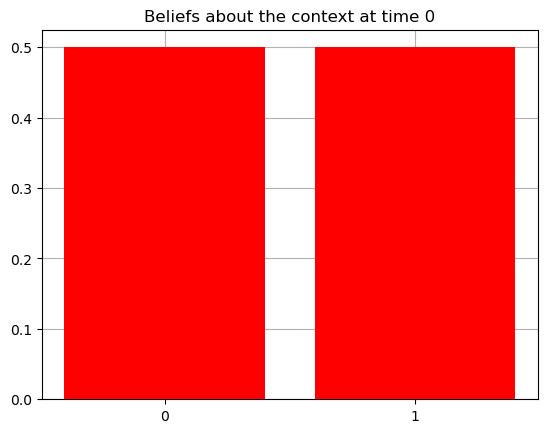

Action at time 0: Get-hint
Reward at time 0: Null


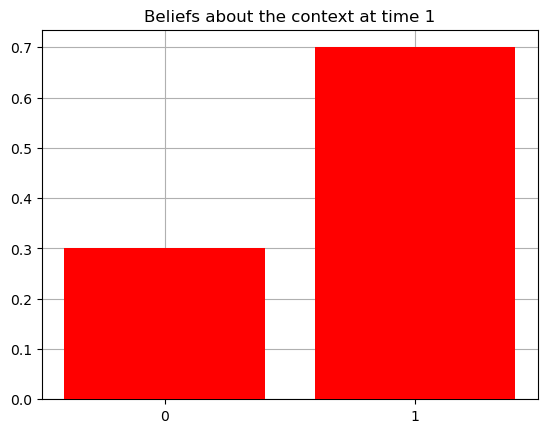

Action at time 1: Get-hint
Reward at time 1: Null


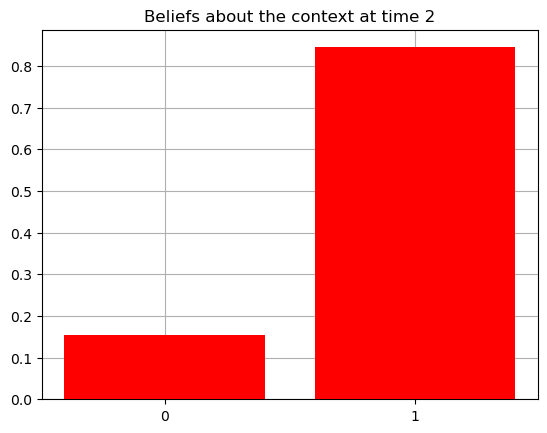

Action at time 2: Play-right
Reward at time 2: Reward


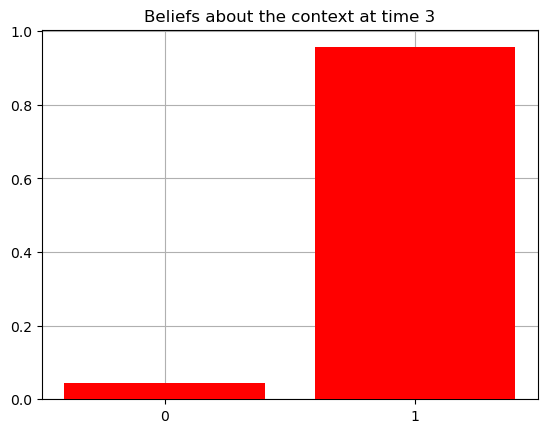

Action at time 3: Play-right
Reward at time 3: Reward


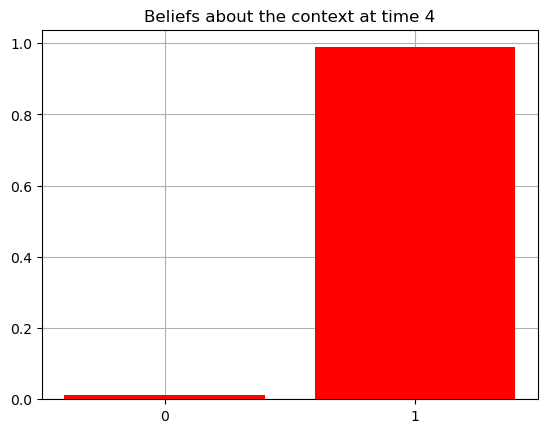

Action at time 4: Play-right
Reward at time 4: Reward


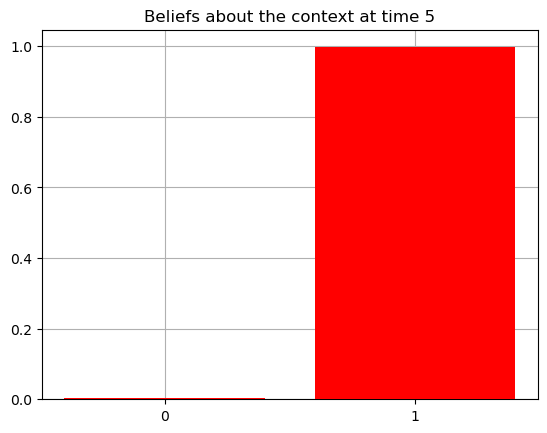

Action at time 5: Play-right
Reward at time 5: Loss


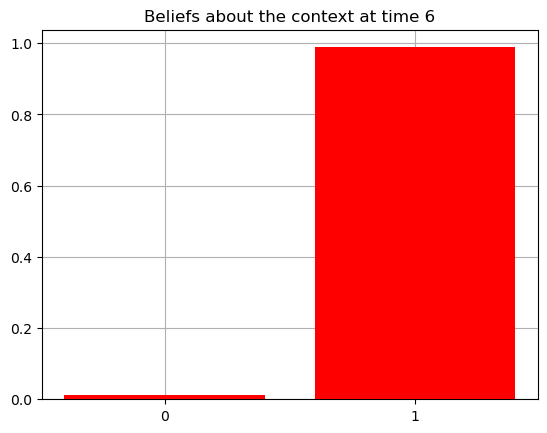

Action at time 6: Play-right
Reward at time 6: Reward


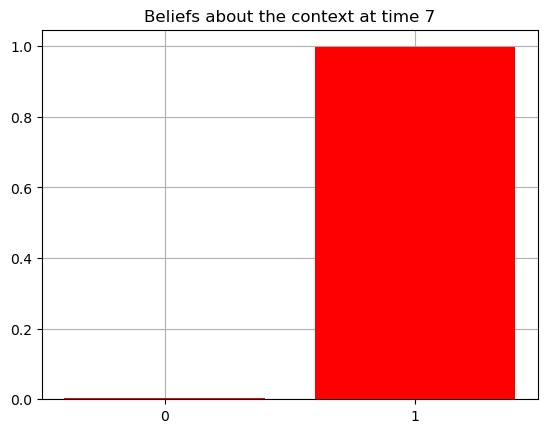

Action at time 7: Play-right
Reward at time 7: Reward


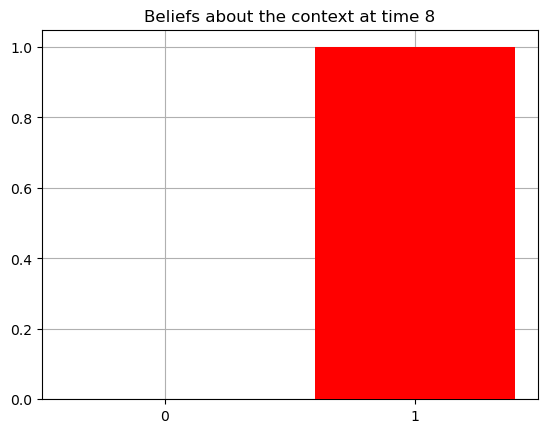

Action at time 8: Play-right
Reward at time 8: Reward


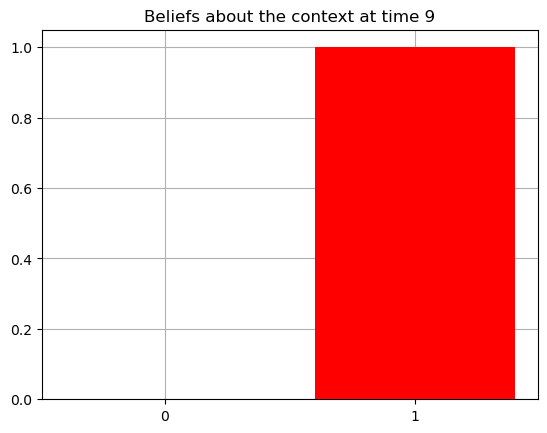

Action at time 9: Play-right
Reward at time 9: Reward


In [22]:
p_hint_env = 1.0 # this is the "true" accuracy of the hint - i.e. how often does the hint actually signal which arm is better. REMEMBER: THIS IS INDEPENDENT OF HOW YOU PARAMETERIZE THE A MATRIX FOR THE HINT MODALITY
p_reward_env = 0.7 # this is the "true" reward probability - i.e. how often does the better arm actually return a reward, as opposed to a loss. REMEMBER: THIS IS INDEPENDENT OF HOW YOU PARAMETERIZE THE A MATRIX FOR THE REWARD MODALITY
env = TwoArmedBandit(p_hint = p_hint_env, p_reward = p_reward_env)
print(f'Context: {env.context}')

T = 10

# my_agent = Agent(A = A, B = B, C = C, D = D) # in case you want to re-define the agent, you can run this again

run_active_inference_loop(my_agent, env, T = T)

Context: Right-Better


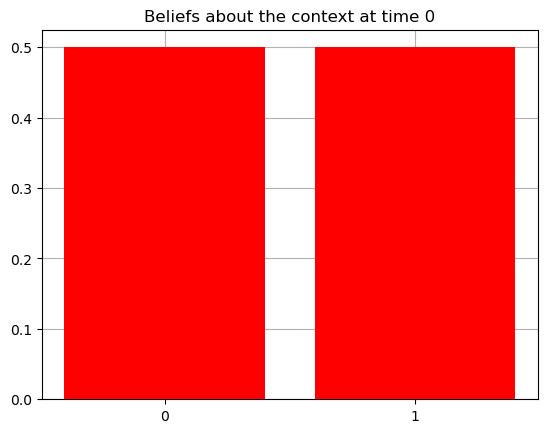

Action at time 0: Play-left
Reward at time 0: Loss


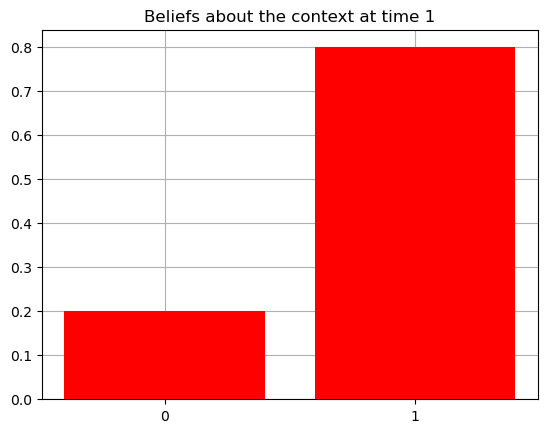

Action at time 1: Play-right
Reward at time 1: Reward


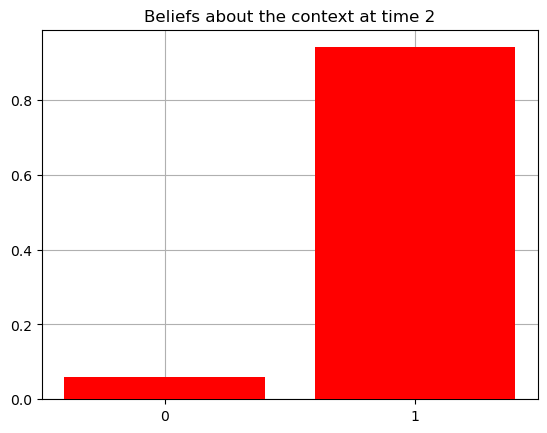

Action at time 2: Play-right
Reward at time 2: Reward


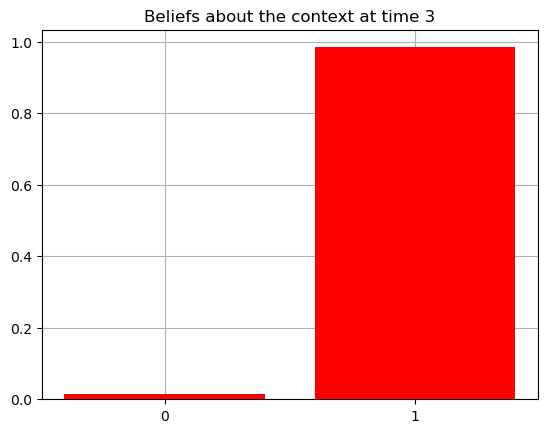

Action at time 3: Play-right
Reward at time 3: Reward


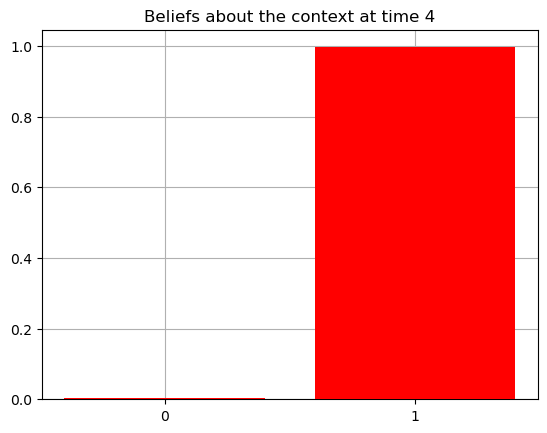

Action at time 4: Play-right
Reward at time 4: Loss


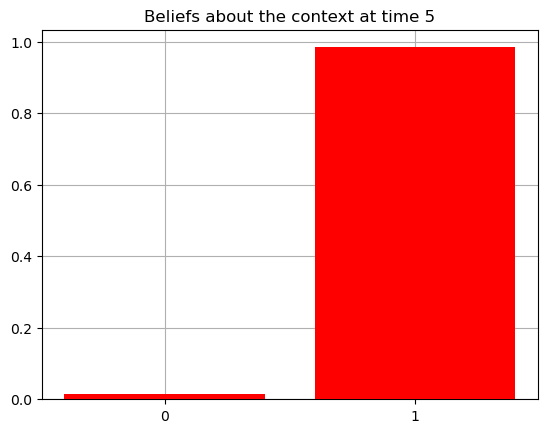

Action at time 5: Play-right
Reward at time 5: Loss


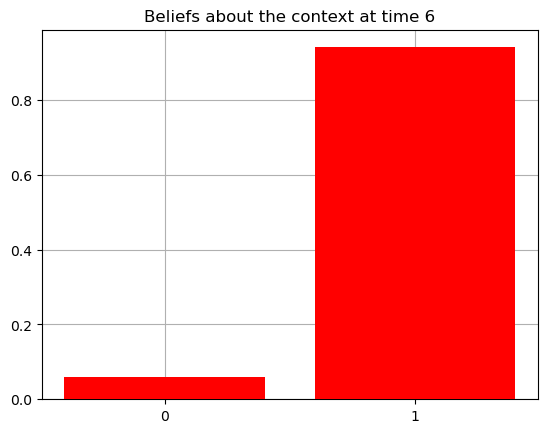

Action at time 6: Play-right
Reward at time 6: Reward


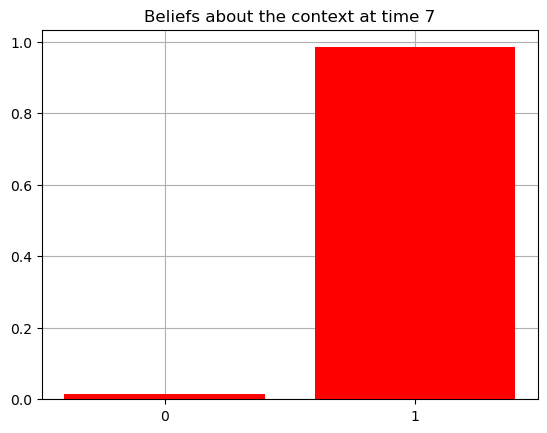

Action at time 7: Play-right
Reward at time 7: Reward


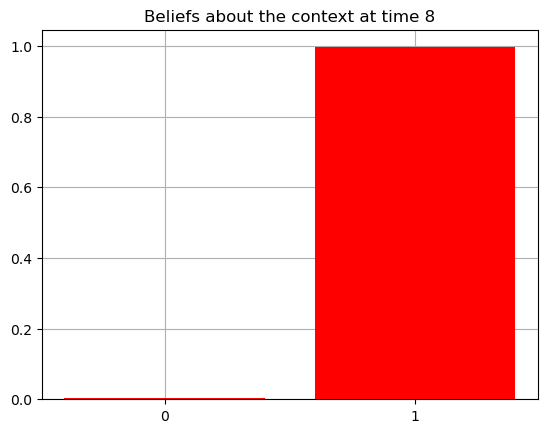

Action at time 8: Play-right
Reward at time 8: Reward


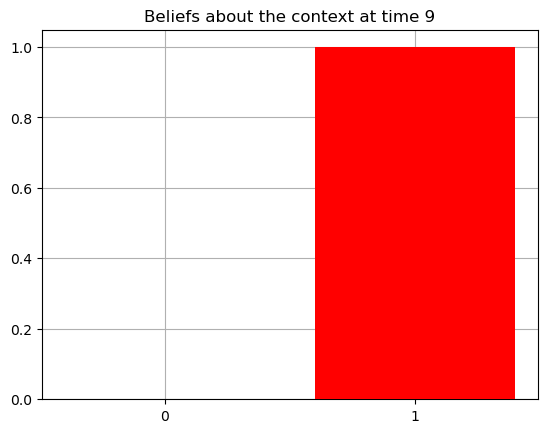

Action at time 9: Play-right
Reward at time 9: Reward


In [23]:
# change the 'shape' of the agent's reward function
C[1][1] = 0.0 # makes the Loss "less aversive" than before (higher prior prior probability assigned to seeing the Loss outcome). This should make the agent less risk-averse / willing to explore both arms, under uncertainty

my_agent = Agent(A = A, B = B, C = C, D = D) # redefine the agent with the new preferences
env = TwoArmedBandit(p_hint = 0.8, p_reward = 0.8) # re-initialize the environment -- this time, the hint is not always accurate (`p_hint = 0.8`)
print(f'Context: {env.context}')

run_active_inference_loop(my_agent, env, T = T)